# DQ1 — Confronto PPO (on-policy) vs SAC (off-policy)

Questo notebook analizza i risultati della prima domanda di ricerca del progetto StableHover. Non addestra né valuta modelli: legge gli artefatti già prodotti dagli script del progetto e ne ricava le figure e le tabelle finali, esportandole in `results/`.

La provenienza dei dati è la seguente. L'addestramento dei sei modelli (PPO e SAC, seed 0/1/2) è svolto da `src/train.py`, orchestrato da `scripts/run_dq1.sh`; durante l'addestramento il callback di valutazione salva le valutazioni periodiche in `evaluations.npz`, da cui ricavo le curve di convergenza. La misura del Crash Rate sotto perturbazioni è prodotta da `src/evaluate.py` (orchestrato da `scripts/run_eval_sweep_dq1.sh`) e raccolta da `scripts/aggregate_eval.py` nel file `experiments/dq1/eval_sweep_results.csv`. 
Il funzionamento dettagliato di ciascuno script è documentato nel `README.md`.

**Domanda di ricerca 1 (Memoria vs. Reattività):** In un task di hovering spaziale, un algoritmo off-policy basato sulla memorizzazione dell'esperienza passata garantisce un tasso di schianti (Crash Rate) inferiore e una convergenza più stabile rispetto a un algoritmo on-policy puramente reattivo?

Una prima valutazione a condizioni nominali non separava i due algoritmi: entrambi raggiungono lo 0% di schianti (effetto soffitto). Per rendere il Crash Rate una metrica informativa ho introdotto uno sweep di severità delle condizioni iniziali, descritto nella sezione 1.

## Setup e percorsi

La cella seguente importa le librerie di analisi e definisce i percorsi del progetto a partire dalla posizione del notebook, così da funzionare indipendentemente dalla cartella di lavoro. `RUNS` punta alle cartelle dei singoli run (`ppo_seed0` … `sac_seed2`); `FIG` e `TAB` sono le cartelle di output per figure e tabelle finali. La verifica finale conferma che il file aggregato del Crash Rate sia raggiungibile prima di procedere.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DQ1  = ROOT / "experiments" / "dq1"
RUNS = DQ1 / "results"                 # cartelle per-run: ppo_seed0 ... sac_seed2
FIG  = ROOT / "results" / "figures"
TAB  = ROOT / "results" / "tables"
FIG.mkdir(parents=True, exist_ok=True)
TAB.mkdir(parents=True, exist_ok=True)

ALGOS = ["ppo", "sac"]
SEEDS = [0, 1, 2]
print("ROOT:", ROOT)
print("CSV trovato:", (DQ1 / "eval_sweep_results.csv").exists())

ROOT: /Users/lucabellu/drone-rl
CSV trovato: True


## 1. Crash Rate sotto perturbazioni

Il Crash Rate misura la frazione di episodi in cui il drone esce dall'inviluppo di volo sicuro. A condizioni nominali non discrimina i due algoritmi, perché entrambi raggiungono lo 0%. Per renderlo informativo, in valutazione ogni episodio parte da una condizione disturbata (offset di posizione, inclinazione iniziale e un impulso di velocità lineare e angolare a `t=0`), la cui intensità è scalata da un parametro di severità su cinque livelli. Le condizioni iniziali sono generate con lo stesso seed per tutti i modelli: a parità di severità, PPO e SAC affrontano esattamente la stessa sequenza di episodi, quindi le differenze osservate dipendono dalla policy e non dalla variabilità campionaria.

La cella seguente carica i risultati dei 30 esperimenti di valutazione (2 algoritmi × 3 seed × 5 livelli di severità) e li aggrega per algoritmo e severità, calcolando media e deviazione standard del Crash Rate sui tre seed di addestramento.

In [2]:
df = pd.read_csv(DQ1 / "eval_sweep_results.csv")

agg = (df.groupby(["algo", "severity"])
         .agg(crash_mean=("crash_rate_pct", "mean"),
              crash_std =("crash_rate_pct", "std"),
              ret_mean  =("mean_return", "mean"),
              ret_std   =("mean_return", "std"))
         .reset_index())
agg

,algo,severity,crash_mean,crash_std,ret_mean,ret_std
0,ppo,1.0,0.000000,0.000000,483.808867,0.125722
1,ppo,2.0,10.666667,13.279056,435.370800,59.242304
2,ppo,3.0,48.333333,17.616280,260.078100,81.637189
3,ppo,4.0,76.333333,10.692677,122.630233,50.484526
4,ppo,5.0,85.333333,8.082904,75.080167,37.637103
5,sac,1.0,0.000000,0.000000,483.218933,0.650932
6,sac,2.0,0.333333,0.577350,478.180867,1.559237
7,sac,3.0,8.000000,2.000000,425.737767,7.765148
8,sac,4.0,31.666667,9.865766,300.461500,35.275408
9,sac,5.0,60.000000,10.535654,173.056867,39.083989


La figura riporta il Crash Rate medio in funzione della severità, con la banda pari a ± una deviazione standard tra i tre seed. La larghezza della banda è una misura della consistenza dell'algoritmo al variare del seme di addestramento. La figura è salvata in `results/figures/`.

Salvato: /Users/lucabellu/drone-rl/results/figures/dq1_crashrate_vs_severity.png


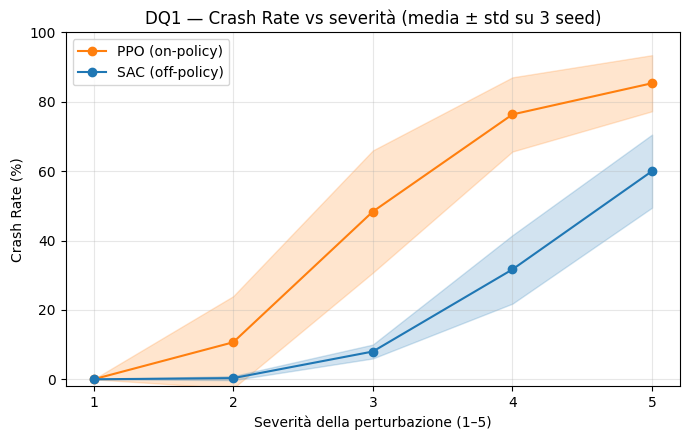

In [3]:
fig, ax = plt.subplots(figsize=(7, 4.5))
colors = {"ppo": "tab:orange", "sac": "tab:blue"}
labels = {"ppo": "PPO (on-policy)", "sac": "SAC (off-policy)"}

for algo in ALGOS:
    d = agg[agg["algo"] == algo].sort_values("severity")
    ax.plot(d["severity"], d["crash_mean"], marker="o", color=colors[algo], label=labels[algo])
    ax.fill_between(d["severity"], d["crash_mean"] - d["crash_std"],
                    d["crash_mean"] + d["crash_std"], color=colors[algo], alpha=0.2)

ax.set_xlabel("Severità della perturbazione (1–5)")
ax.set_ylabel("Crash Rate (%)")
ax.set_title("DQ1 — Crash Rate vs severità (media ± std su 3 seed)")
ax.set_xticks([1, 2, 3, 4, 5]); ax.set_ylim(-2, 100)
ax.grid(True, alpha=0.3); ax.legend()
fig.tight_layout()
out = FIG / "dq1_crashrate_vs_severity.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
print("Salvato:", out)
plt.show()

## 2. Convergenza durante l'addestramento

Le curve di convergenza descrivono come la performance evolve durante l'addestramento. La fonte è il file `evaluations.npz` di ciascun run, prodotto dal callback di valutazione in `src/train.py`: a intervalli regolari di passi l'addestramento viene sospeso e la policy corrente è valutata su alcuni episodi, la cui ricompensa media costituisce un punto della curva.

La cella seguente, per ogni algoritmo, calcola la media della ricompensa sugli episodi di valutazione per ciascun seed e aggrega i tre seed in media e deviazione standard. La banda rappresenta la variabilità tra seed: una banda stretta indica una convergenza riproducibile, poco sensibile al seme casuale. L'addestramento usa un budget identico di 500.000 passi per entrambi gli algoritmi, senza early stopping, per garantire un confronto equo.

In [4]:
def algo_curve(algo):
    series = []
    for s in SEEDS:
        d = np.load(RUNS / f"{algo}_seed{s}" / "evaluations.npz")
        ts = d["timesteps"]
        series.append(d["results"].mean(axis=1))   # media sugli episodi, per ogni valutazione
    L = min(len(x) for x in series)                 # allineo le lunghezze tra seed
    ts = np.load(RUNS / f"{algo}_seed0" / "evaluations.npz")["timesteps"][:L]
    M = np.vstack([x[:L] for x in series])          # (3 seed, L valutazioni)
    return ts, M.mean(axis=0), M.std(axis=0)

curves = {a: algo_curve(a) for a in ALGOS}
for a in ALGOS:
    ts, m, sd = curves[a]
    print(f"{a}: {len(ts)} valutazioni | reward finale medio = {m[-1]:.1f}")

ppo: 50 valutazioni | reward finale medio = 473.8
sac: 50 valutazioni | reward finale medio = 469.2


La figura sovrappone le curve di convergenza dei due algoritmi (media ± std tra seed) sull'intero budget di addestramento, permettendo di confrontare la velocità di salita, la stabilità della fase transitoria e il livello raggiunto a regime. È salvata in `results/figures/`.

Salvato: /Users/lucabellu/drone-rl/results/figures/dq1_convergence.png


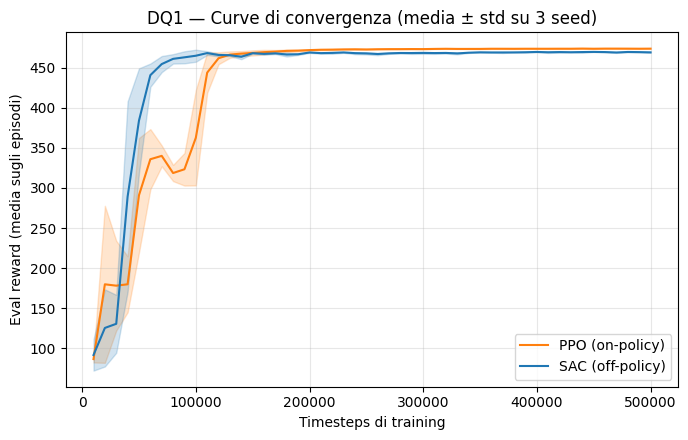

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for algo in ALGOS:
    ts, m, sd = curves[algo]
    ax.plot(ts, m, color=colors[algo], label=labels[algo])
    ax.fill_between(ts, m - sd, m + sd, color=colors[algo], alpha=0.2)

ax.set_xlabel("Timesteps di training")
ax.set_ylabel("Eval reward (media sugli episodi)")
ax.set_title("DQ1 — Curve di convergenza (media ± std su 3 seed)")
ax.grid(True, alpha=0.3); ax.legend()
fig.tight_layout()
out = FIG / "dq1_convergence.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
print("Salvato:", out)
plt.show()

## 3. Sintesi quantitativa

La cella seguente esporta i risultati del Crash Rate in due tabelle salvate in `results/tables/`: una versione completa con media e deviazione standard di Crash Rate e ricompensa per ogni combinazione algoritmo–severità, e una versione sintetica nel formato "media ± std" pivottata per severità, pensata per l'inserimento diretto nella presentazione.

In [6]:
agg.to_csv(TAB / "dq1_crashrate_summary.csv", index=False)

piv = agg.assign(cell=agg["crash_mean"].round(1).astype(str) + " ± " + agg["crash_std"].round(1).astype(str))
piv = piv.pivot(index="severity", columns="algo", values="cell")
piv.to_csv(TAB / "dq1_crashrate_table.csv")
print("Salvate 2 tabelle in results/tables/")
piv

Salvate 2 tabelle in results/tables/


algo,ppo,sac
severity,,
1.0,0.0 ± 0.0,0.0 ± 0.0
2.0,10.7 ± 13.3,0.3 ± 0.6
3.0,48.3 ± 17.6,8.0 ± 2.0
4.0,76.3 ± 10.7,31.7 ± 9.9
5.0,85.3 ± 8.1,60.0 ± 10.5


### Velocità di convergenza

Per quantificare l'impressione visiva delle curve, la cella seguente individua il numero di passi a cui ciascun algoritmo supera per la prima volta una soglia di ricompensa di valutazione. La soglia di 400 corrisponde a circa l'83% della ricompensa massima teorica (~480) ed è adottata come criterio convenzionale di "task risolto": è una scelta di reporting dichiarata, non un parametro del modello.

In [7]:
THR = 400.0   # ~83% del reward massimo teorico (~480); soglia di "task risolto", scelta di reporting
print(f"Soglia eval reward = {THR}")
for algo in ALGOS:
    ts, m, sd = curves[algo]
    mask = m >= THR
    if mask.any():
        idx = int(np.argmax(mask))
        print(f"{algo}: primo superamento di {THR:.0f} a ~{ts[idx]:,} timesteps")
    else:
        print(f"{algo}: soglia mai raggiunta")

Soglia eval reward = 400.0
ppo: primo superamento di 400 a ~110,000 timesteps
sac: primo superamento di 400 a ~60,000 timesteps


## 4. Verdetto DQ1

**Domanda di ricerca:** un algoritmo off-policy (memoria) garantisce Crash Rate inferiore e convergenza più stabile di un on-policy puramente reattivo?

**Risposta: sì, su entrambi gli assi.**
- **Crash Rate:** SAC schianta meno a ogni severità, con bande mai sovrapposte (sev3: ~8% vs ~48%): più robusto e più consistente tra seed.
- **Convergenza:** stesso plateau finale (~470), ma SAC supera reward=400 a ~60k passi contro ~110k di PPO, con banda più stretta in salita.

### Limiti e precisazioni metodologiche
- Il plateau finale è equivalente per le due famiglie: il vantaggio di SAC è in velocità di convergenza, stabilità tra seed e robustezza alle perturbazioni, non nella performance asintotica. Riporto l'equivalenza esplicitamente per non sovrastimare il risultato.
- Il confronto è a livello di **famiglie** (on-policy vs off-policy), con PPO e SAC come rappresentanti. La maggiore sample-efficiency di SAC non è isolabile alla sola memoria (replay buffer): SAC differisce anche per entropia massimizzata, twin critic e architettura. Il replay buffer è il fattore più plausibile, ma il disegno non isola una singola causa: è un limite dichiarato del confronto.

**Conseguenza:** SAC è il modello portato in DQ2.